# Nama:RONNY RAJAGUKGUK
# NIM:4222301029
# Kelas:ROBOTIC A PAGI
# Assignment 6

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

## EDA

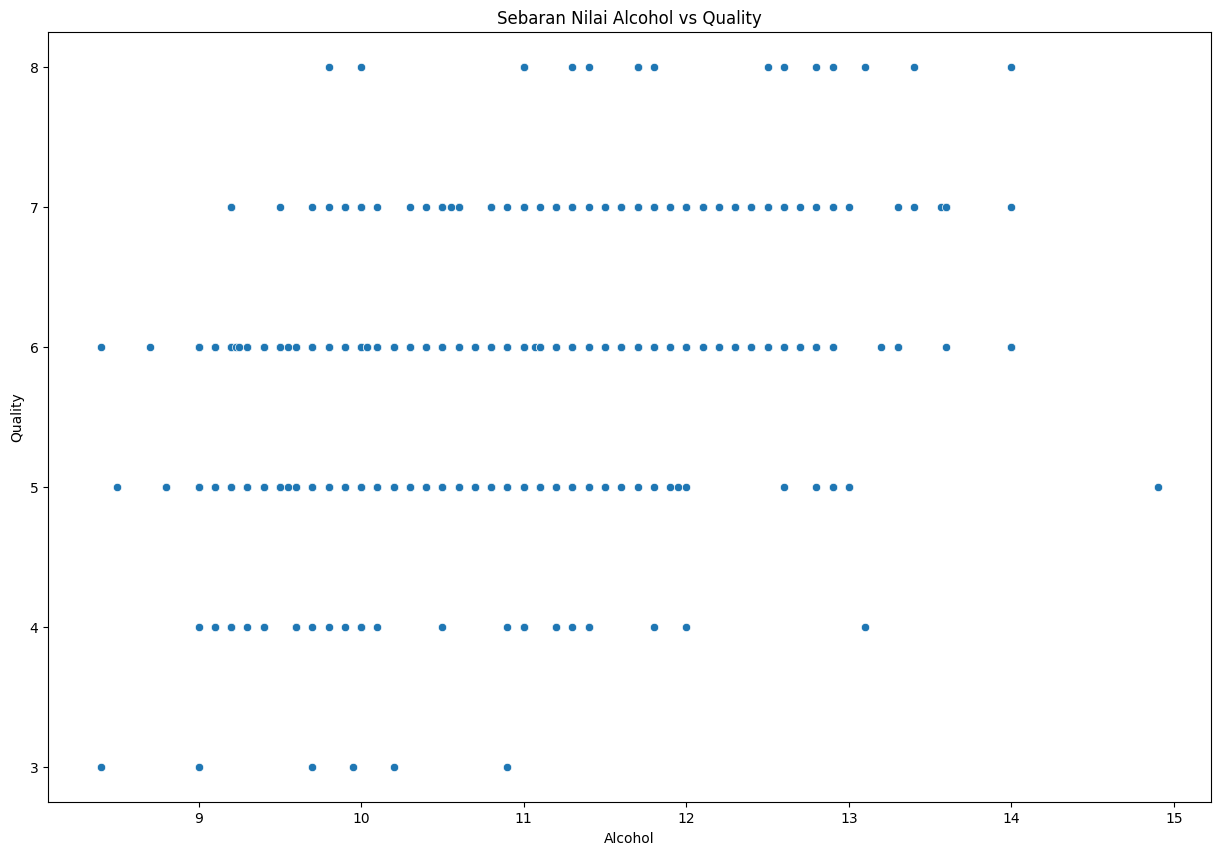

In [11]:
# Scatter Plot Alcohol vs Quality
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality'
)

plt.title('Sebaran Nilai Alcohol vs Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')

plt.show()

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


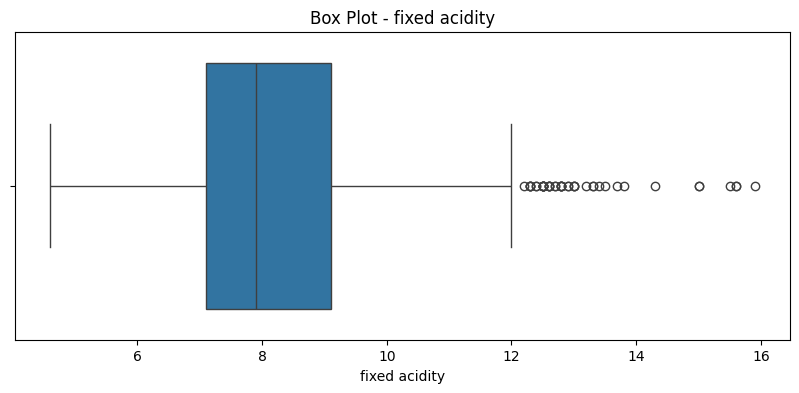

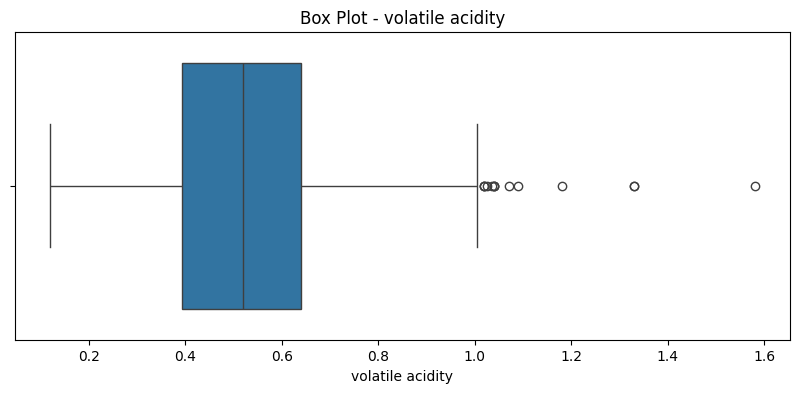

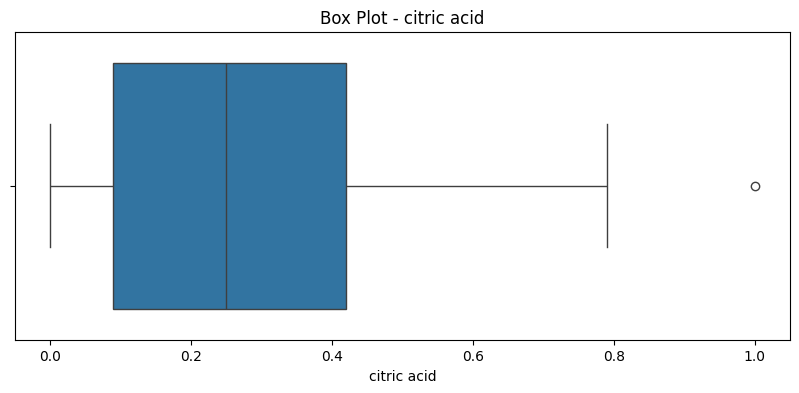

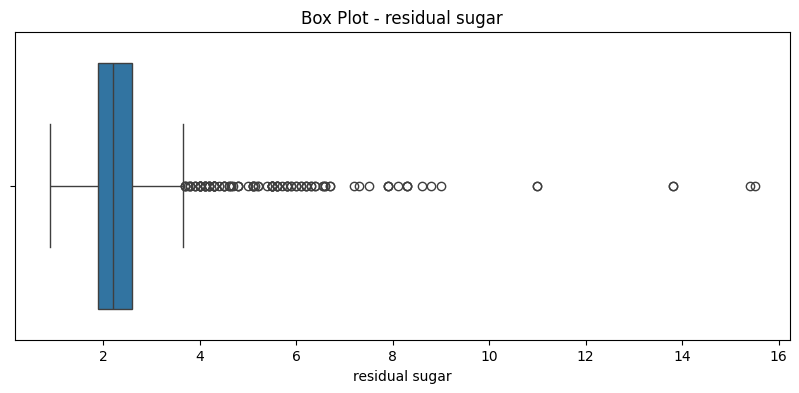

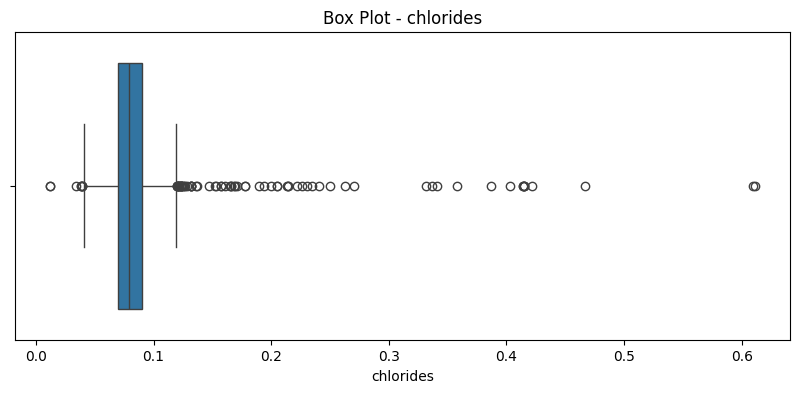

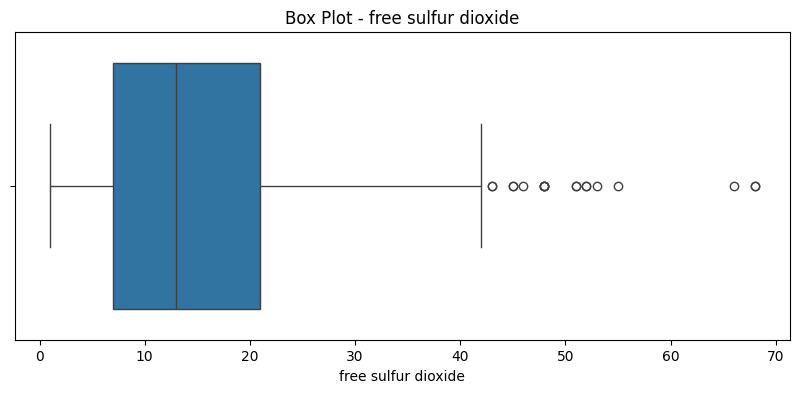

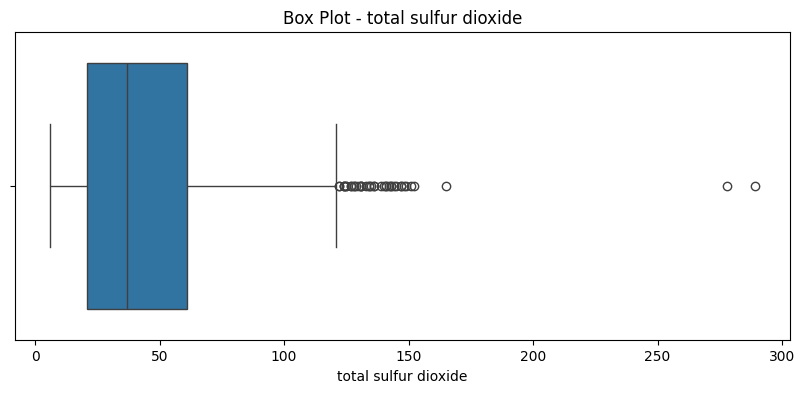

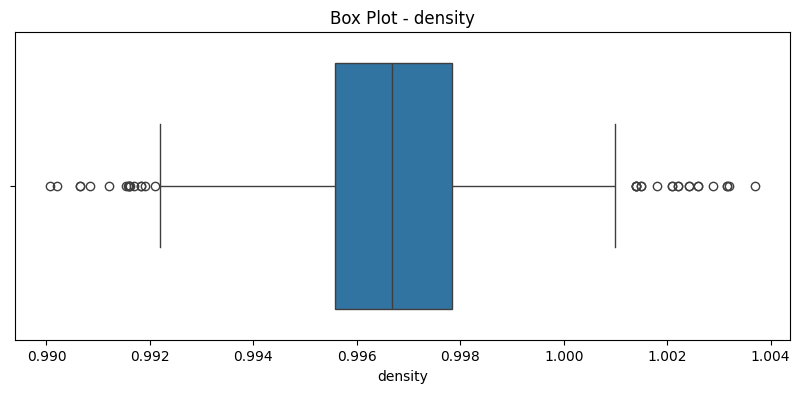

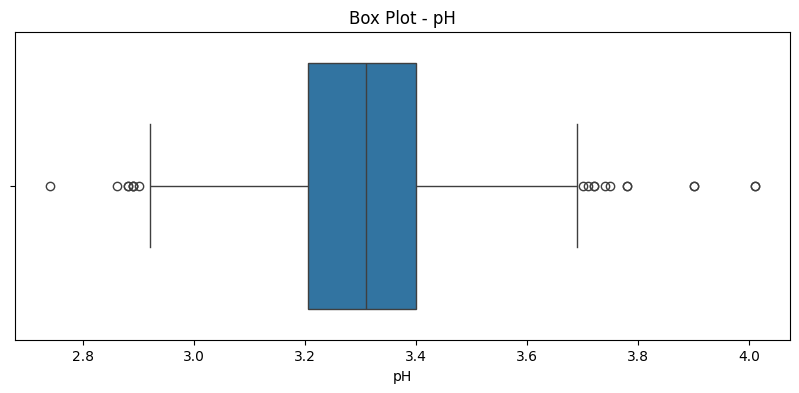

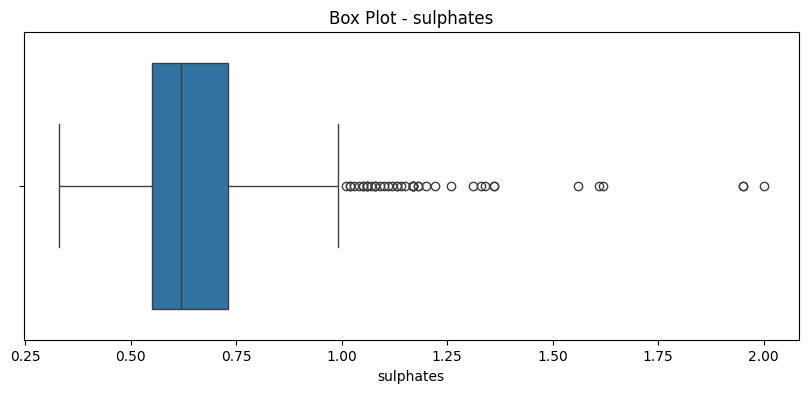

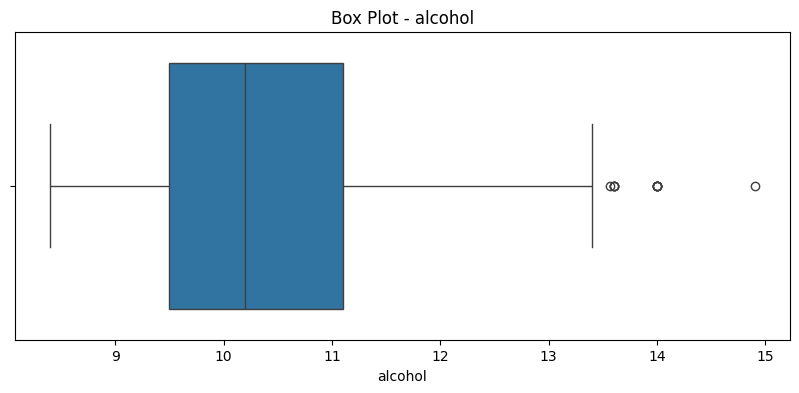

In [12]:
# Box Plot semua fitur (kecuali quality dan Id)
for col in df.columns[:-2]:

    plt.figure(figsize=(10,4))

    sns.boxplot(x=df[col])

    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)

    plt.show()

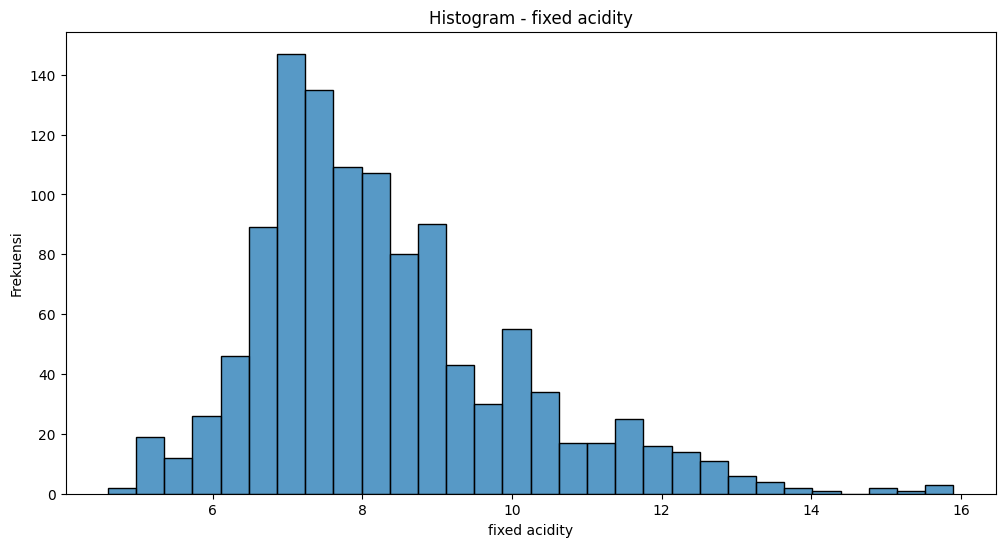

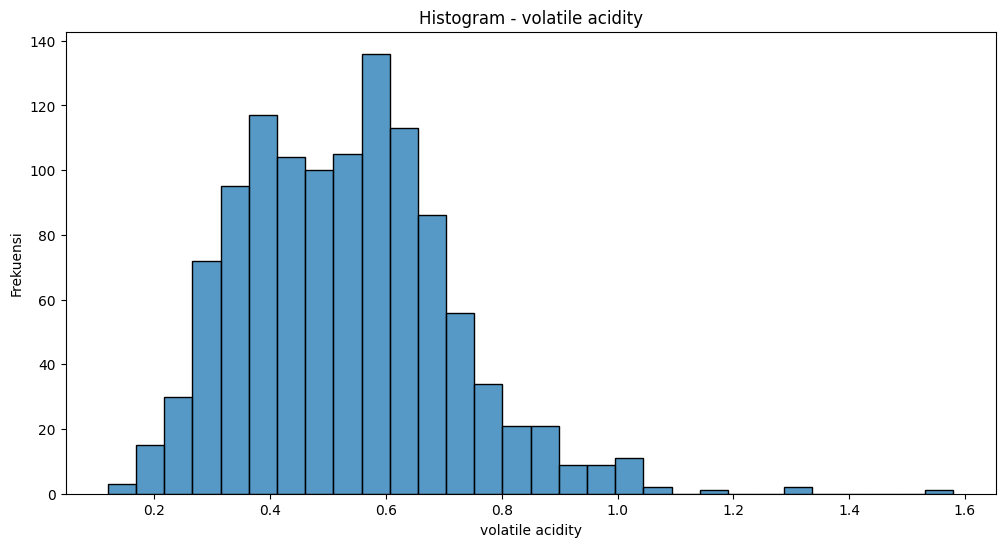

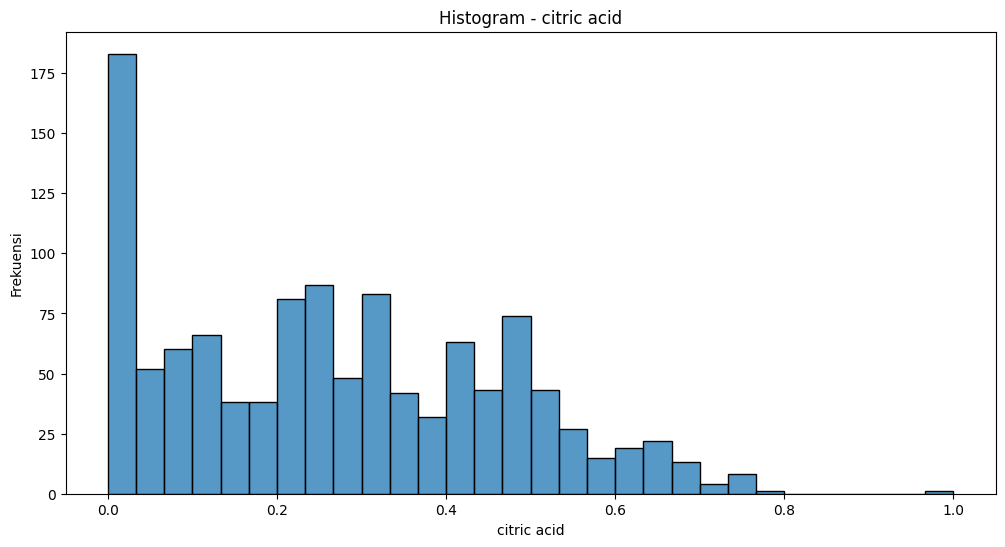

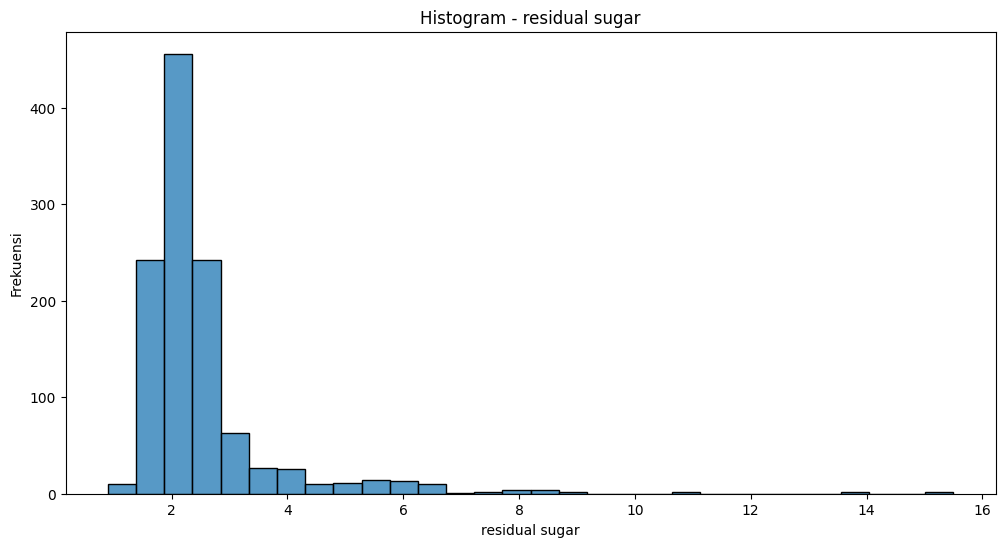

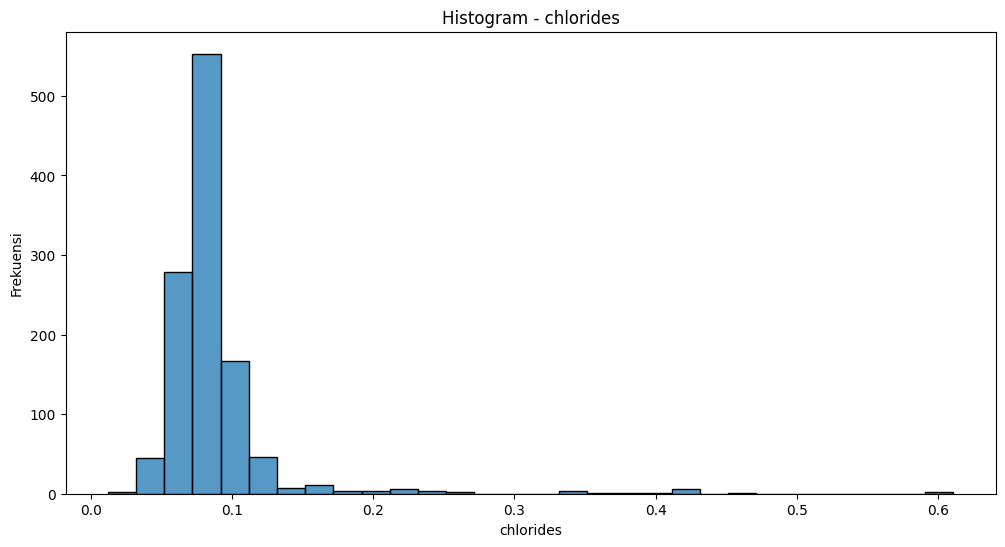

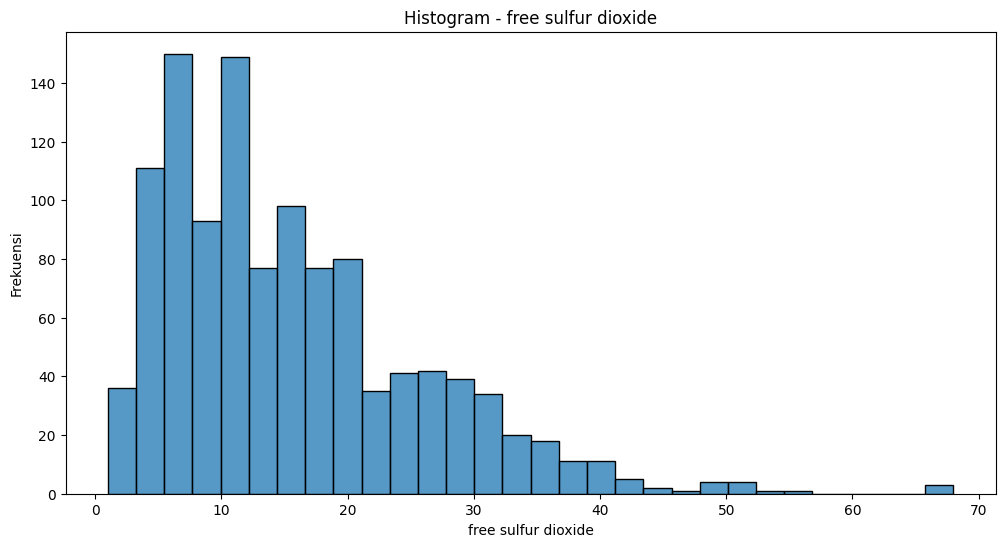

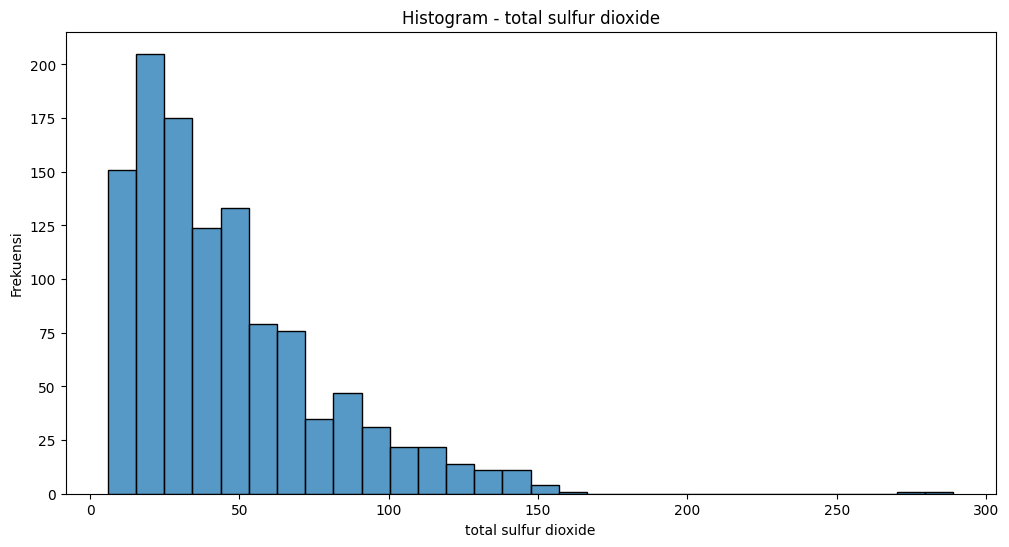

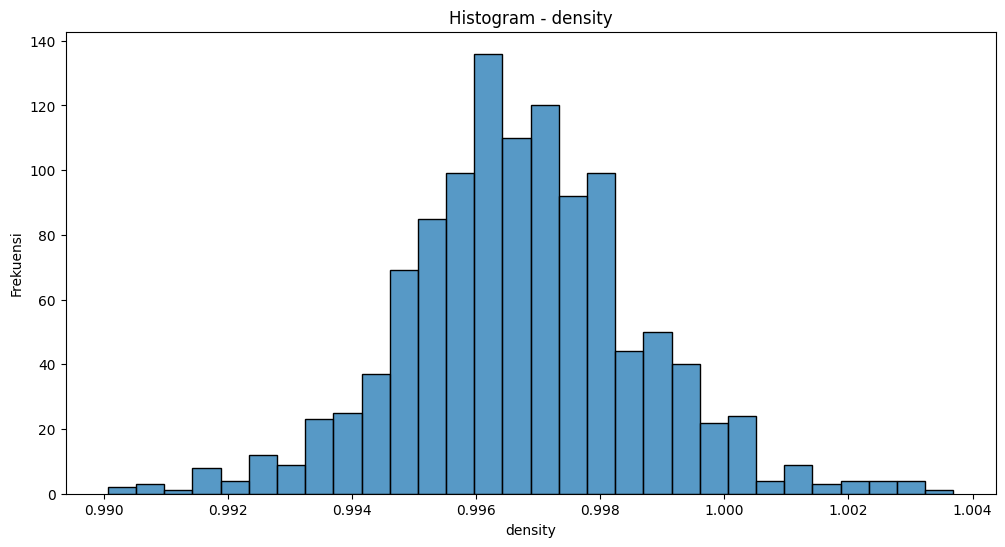

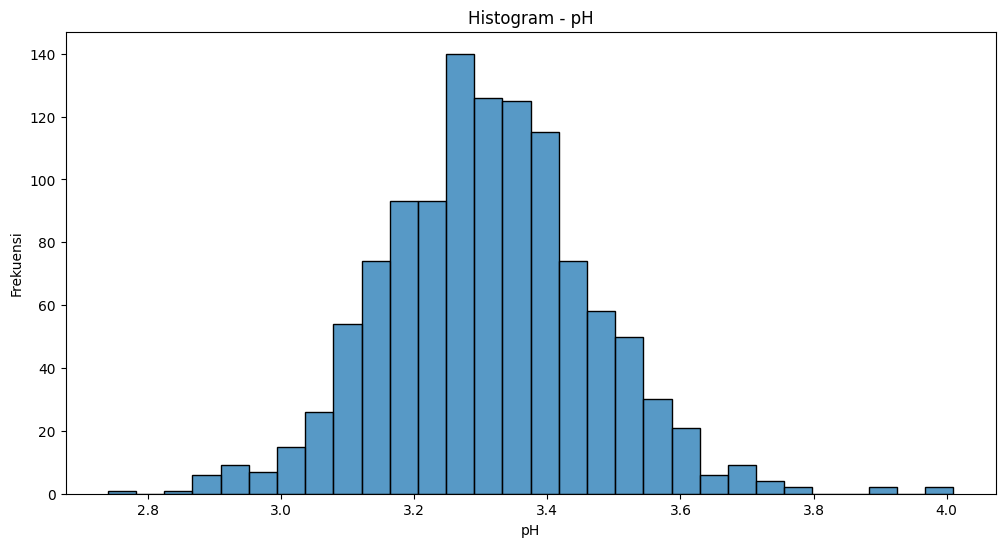

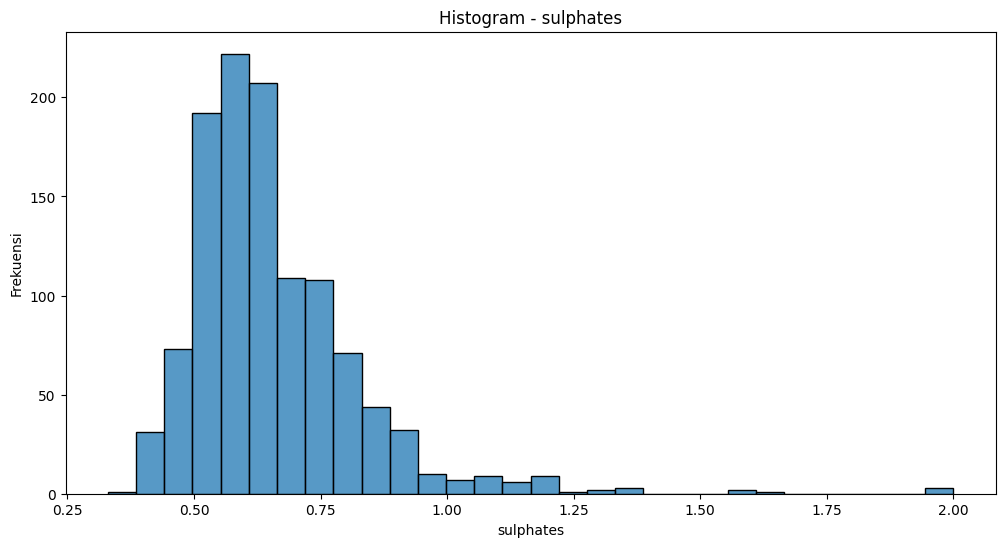

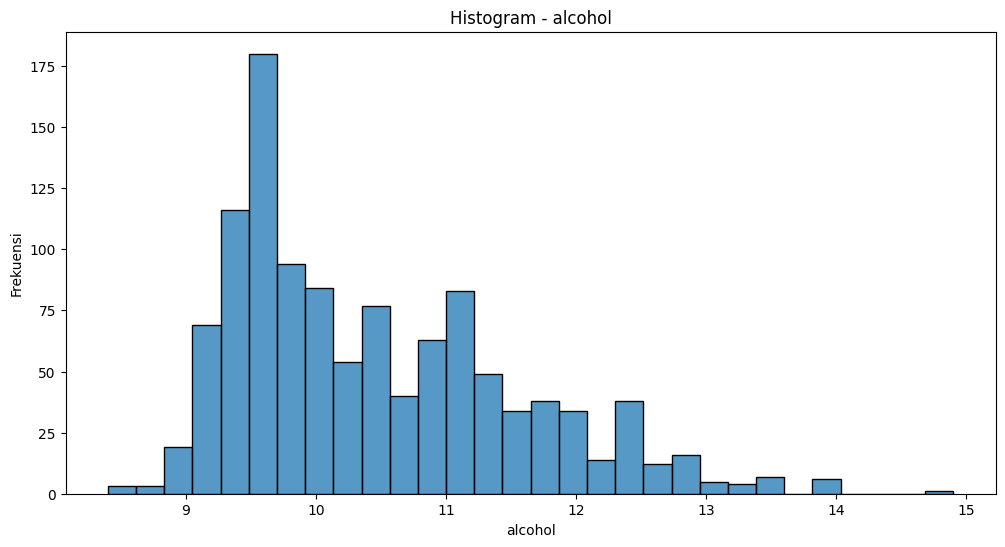

In [13]:
columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for col in columns:

    plt.figure(figsize=(12,6))

    sns.histplot(df[col], bins=30, kde=False)

    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [14]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop: {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop: {df.shape[0]}")

Dataframe dimension before duplication drop: 1143
Dataframe dimension after duplication drop: 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [15]:
fitur_columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[fitur_columns].values
y = df['quality'].values

In [16]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X_std = StandardScaler().fit_transform(X)

df_scalling = pd.DataFrame(
    data=X_std,
    columns=fitur_columns
)

df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [17]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]])

In [18]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

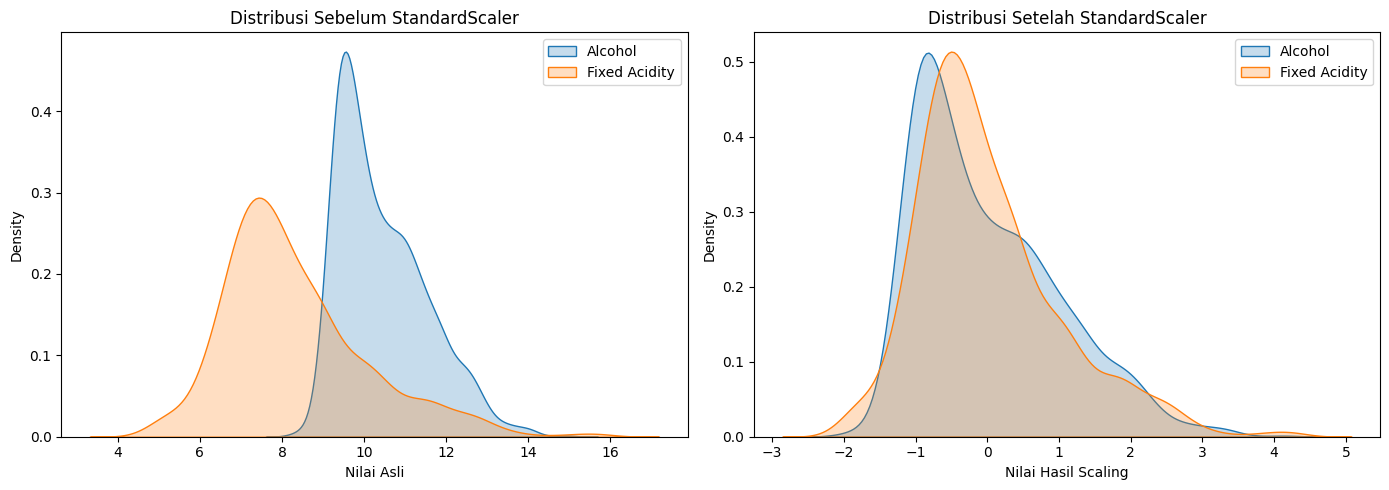

In [19]:
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(14,5)
)

# Sebelum scaling
sns.kdeplot(
    df['alcohol'],
    ax=ax1,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    df['fixed acidity'],
    ax=ax1,
    label='Fixed Acidity',
    fill=True
)

ax1.set_title('Distribusi Sebelum StandardScaler')


# Setelah scaling
sns.kdeplot(
    df_scalling['alcohol'],
    ax=ax2,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    df_scalling['fixed acidity'],
    ax=ax2,
    label='Fixed Acidity',
    fill=True
)

ax2.set_title('Distribusi Setelah StandardScaler')

ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Hasil Scaling')

ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
1. Sebelum dilakukan StandardScaler, fitur pada dataset wine seperti alcohol, fixed acidity, density, dan fitur lainnya memiliki rentang nilai yang berbeda-beda. Beberapa fitur memiliki nilai yang jauh lebih besar dibanding fitur lain sehingga distribusi data belum seimbang.
2. Setelah dilakukan feature scaling menggunakan StandardScaler, seluruh fitur berubah menjadi lebih terstandarisasi dengan rata-rata (mean) mendekati 0 dan standar deviasi mendekati 1, sehingga skala antar fitur menjadi seragam.
3. Proses scaling membuat setiap fitur memiliki bobot yang setara dan mengurangi dominasi fitur dengan rentang nilai yang besar terhadap fitur lain pada proses analisis.
4. Hasil scaling membantu meningkatkan performa algoritma machine learning terutama algoritma yang sensitif terhadap skala data seperti K-Means Clustering, K-Nearest Neighbor (KNN), Support Vector Machine (SVM), dan metode berbasis jarak lainnya.
5. Berdasarkan grafik distribusi sebelum dan sesudah scaling, terlihat bahwa bentuk distribusi data tetap dipertahankan, namun skala nilai menjadi lebih seragam sehingga data lebih siap digunakan pada tahap pemodelan dan analisis lanjutan.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

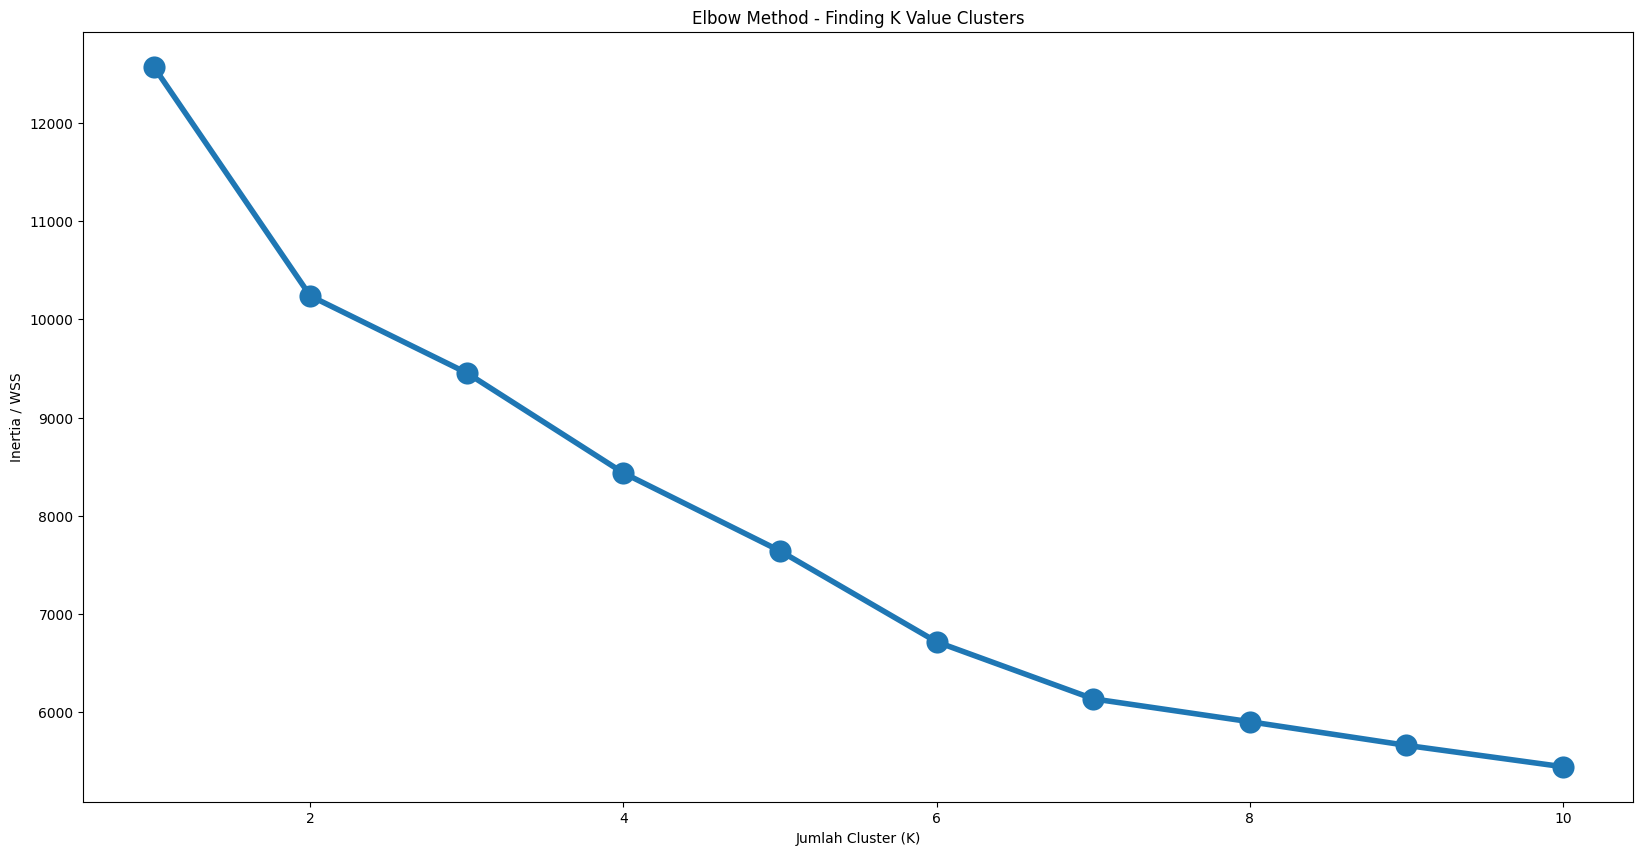

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)
    plt.figure(figsize=(20,10))

sns.lineplot(x=range(1,11), y=inertia, linewidth=4)
sns.scatterplot(x=range(1,11), y=inertia, s=300)
plt.title('Elbow Method - Finding K Value Clusters')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WSS')

plt.show()

In [ ]:
#Dari hasil diatas elbow nya dipilih pada angka 7,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=7, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=7, random_state=0)

In [26]:
df['cluster_elbow'] = kmeans_elbow.labels_

In [24]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,4
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,4
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,6
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,6


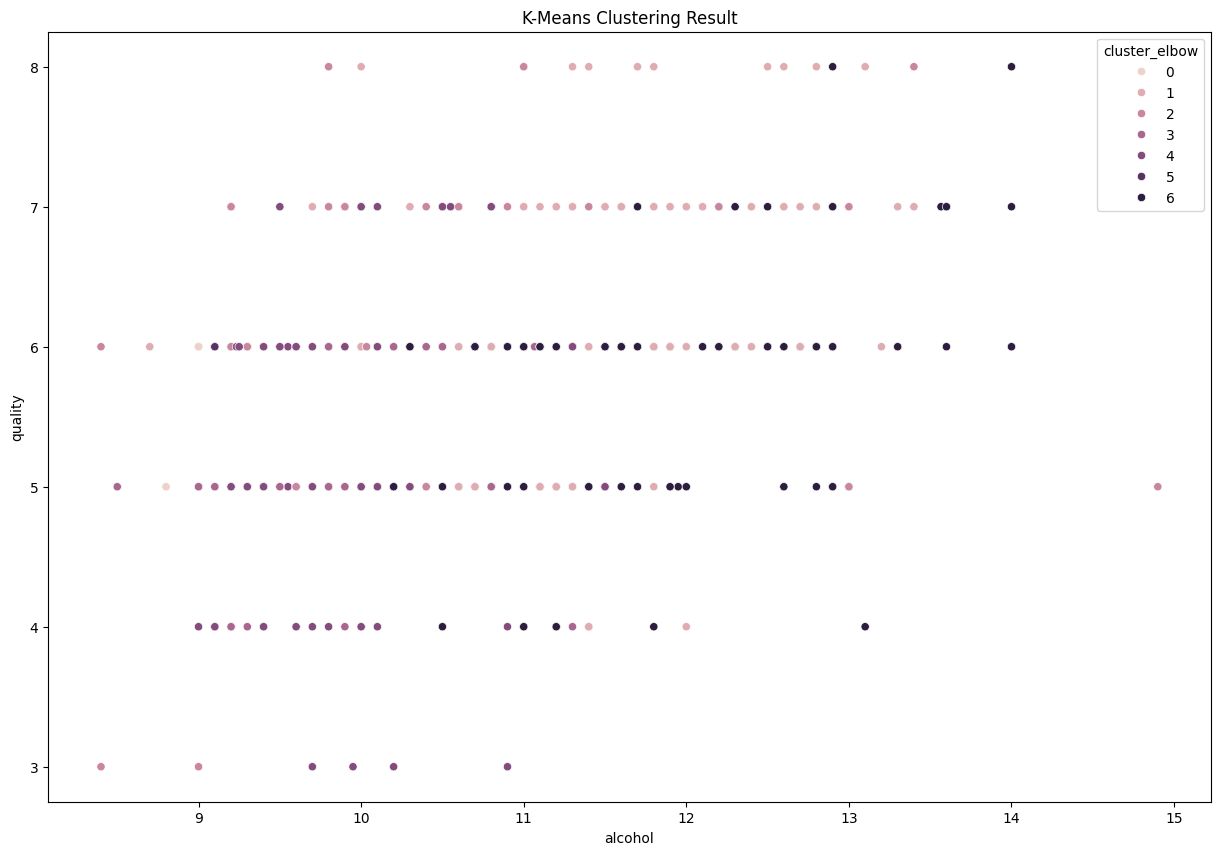

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_elbow')
plt.title('K-Means Clustering Result')
plt.show()

### Bandingkan hasil dengan label anotator

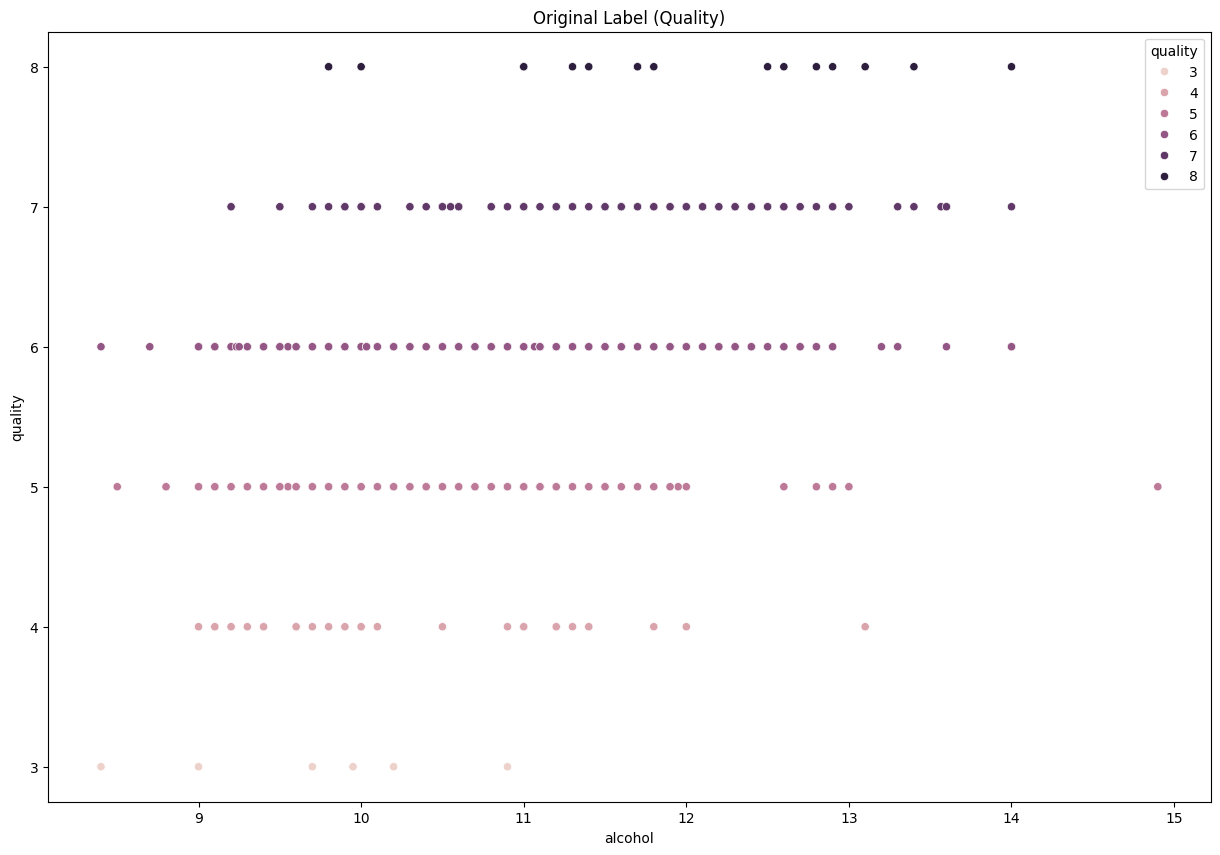

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality')
plt.title('Original Label (Quality)')
plt.show()

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
Hasil di atas menunjukkan bahwa metode Elbow menghasilkan jumlah cluster yang cukup optimal untuk mengelompokkan data wine. Cluster yang terbentuk dapat memisahkan karakteristik data berdasarkan kemiripan fitur-fitur seperti alcohol, acidity, density, dan atribut lainnya.

Dengan kondisi hasil clustering:

1. Cluster 0 → Kelompok wine dengan karakteristik tertentu dan kualitas cenderung pada kategori rendah–menengah.
2. Cluster 1 → Kelompok wine dengan karakteristik kimia yang berbeda, misalnya kadar alkohol atau tingkat keasaman lebih tinggi.
3. Cluster 2 → Kelompok wine dengan distribusi fitur yang relatif seimbang dibanding cluster lain.
4. Cluster 3 → Kelompok wine dengan karakteristik paling berbeda atau memiliki nilai fitur yang menonjol dibanding kelompok lainnya.

Dari visualisasi hasil cluster dan perbandingan dengan label quality, terlihat bahwa metode K-Means mampu membentuk kelompok data berdasarkan kemiripan karakteristik. Namun karena K-Means adalah unsupervised learning, label cluster tidak secara langsung merepresentasikan kualitas wine tertentu, sehingga diperlukan evaluasi lanjutan untuk mengetahui kesesuaian cluster terhadap label asli (quality).

### 2. Via Score Plot

In [1]:
!pip install yellowbrick

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# baca dataset
df = pd.read_csv('WineQT.csv')

# cek data
print(df.head())
print(df.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [33]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

fitur_columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[fitur_columns]

scaler = StandardScaler()

X_std = scaler.fit_transform(X)

df_scalling = pd.DataFrame(
    X_std,
    columns=fitur_columns
)

df_scalling.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382


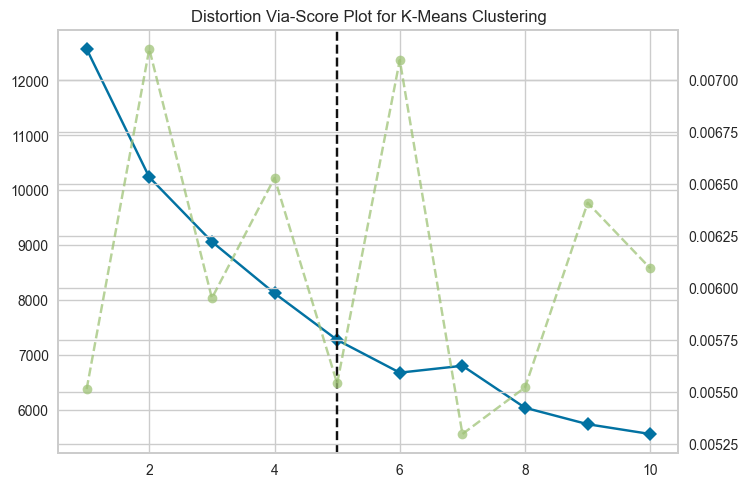

In [34]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

k_means_via = KMeans()

visualizer = KElbowVisualizer(
    k_means_via,
    k=(1,11),
    timings=True
)

visualizer.fit(
    df_scalling.values
)

plt.title(
    'Distortion Via-Score Plot for K-Means Clustering'
)

plt.show()

In [35]:
# Dari hasil diatas K-nya dipilih pada angka 5,
# karena titik distorsinya bertemu pada nilai 5 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=5, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=5, random_state=0)

In [36]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [37]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,4
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,4
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

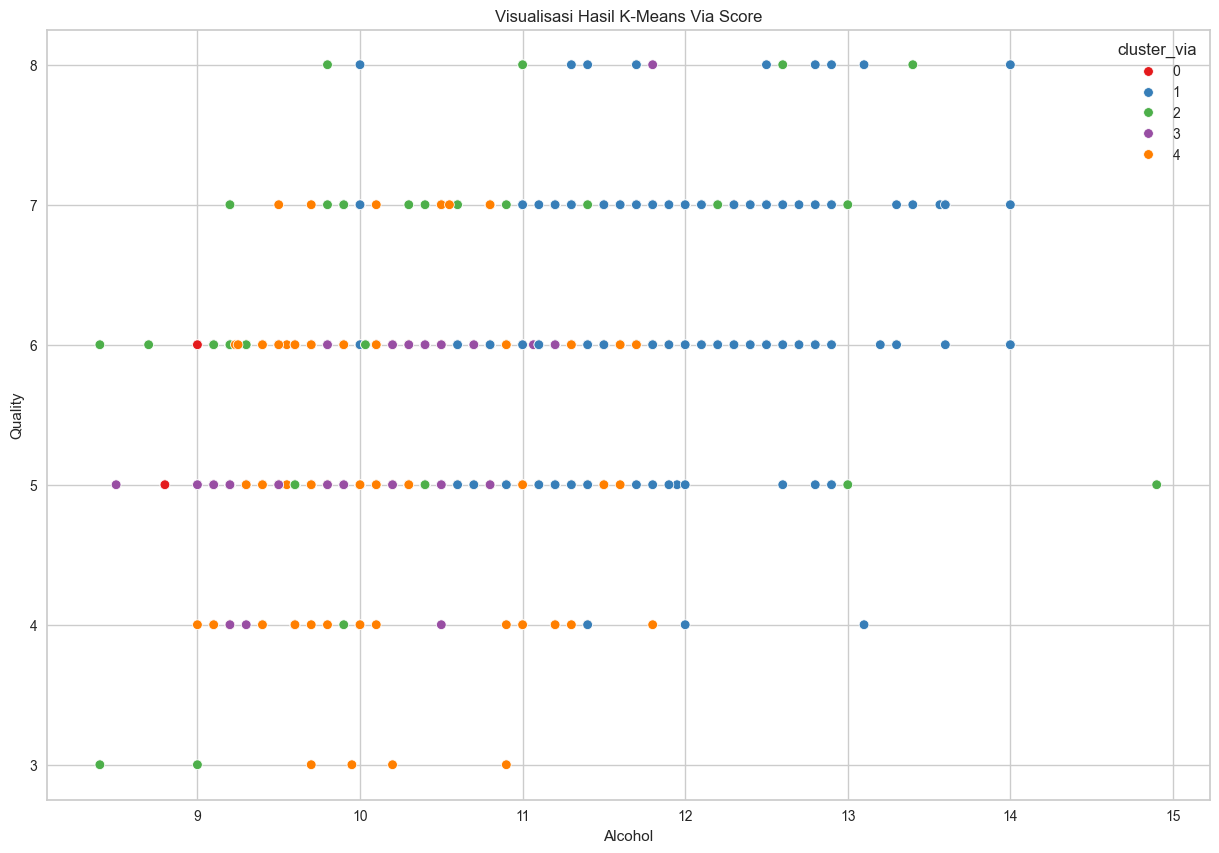

In [38]:
fig, ax = plt.subplots(
    figsize=(15,10)
)

sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality',
    hue='cluster_via',
    palette='Set1'
)

plt.title(
    'Visualisasi Hasil K-Means Via Score'
)

plt.xlabel('Alcohol')
plt.ylabel('Quality')

plt.show()

### Bandingkan dengan label anotator

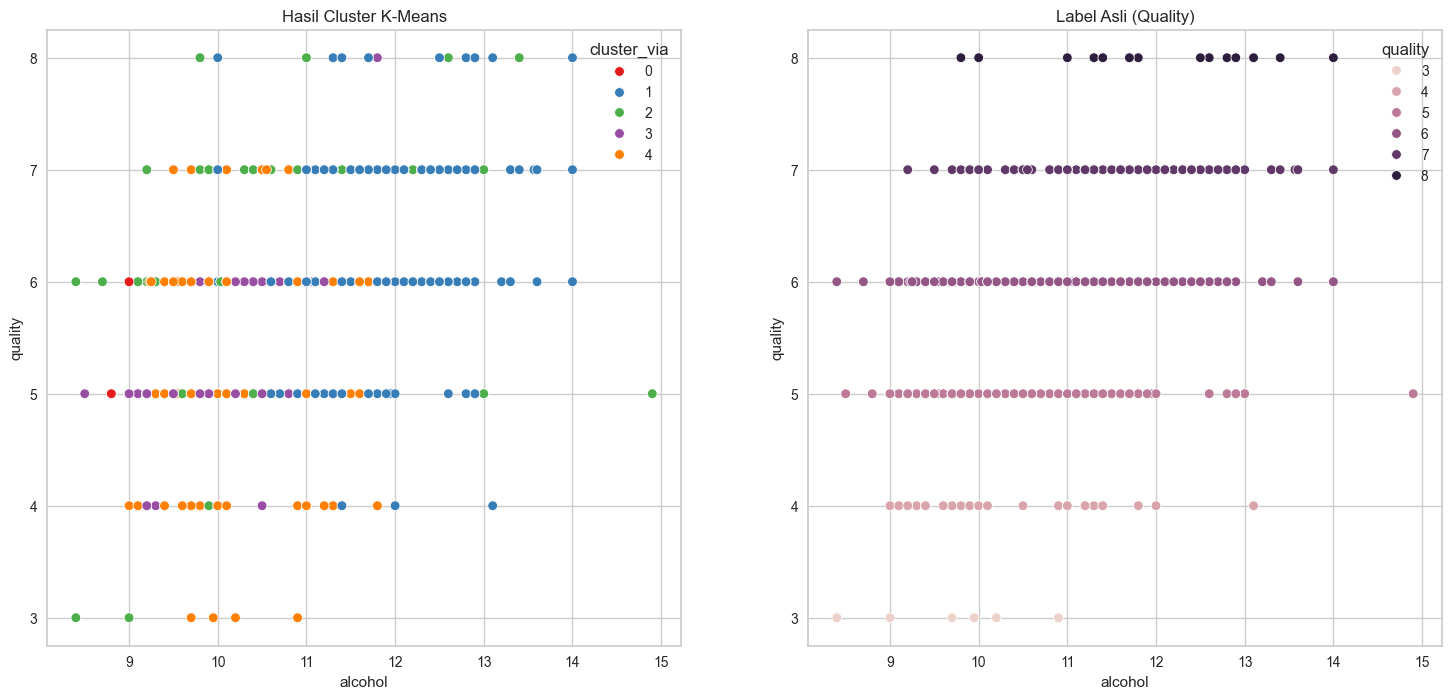

In [39]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(18,8)
)

# Hasil clustering
sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality',
    hue='cluster_via',
    palette='Set1',
    ax=ax1
)

ax1.set_title(
    'Hasil Cluster K-Means'
)

# Label asli quality
sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality',
    hue='quality',
    ax=ax2
)

ax2.set_title(
    'Label Asli (Quality)'
)

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Hasil K-Means dengan K = 5 berhasil mengelompokkan data wine berdasarkan kemiripan karakteristik fitur seperti alcohol, fixed acidity, density, pH, dan atribut lainnya, sehingga data dengan karakteristik serupa berada pada cluster yang sama.
2. Jika dibandingkan dengan label asli quality, hasil clustering menunjukkan pola yang cukup mirip, meskipun masih terdapat beberapa perbedaan. Hal ini terjadi karena K-Means melakukan pengelompokan berdasarkan perhitungan jarak antar data dan kemiripan fitur, sedangkan label quality ditentukan berdasarkan penilaian kualitas wine yang dapat dipengaruhi faktor lain.
3. Perbedaan antara hasil cluster dan label asli menunjukkan bahwa metode unsupervised learning tidak menggunakan informasi label saat proses pelatihan, sehingga hasil pengelompokan murni berdasarkan pola data.
4. Secara keseluruhan, metode K-Means mampu menemukan struktur atau pola tersembunyi pada dataset wine dan dapat digunakan untuk membantu proses analisis karakteristik data secara otomatis.

### Thank you :)